# Violence Detection — CNN+LSTM  (tf.data Streaming Pipeline)

## Why the old version was slow
The previous `load_dataset()` pre-loaded **every frame** from every video into a single NumPy array  
(`~11 810 seqs × 20 frames × 64×64×3 float32 ≈ 14 GB`).  
This caused:
- 19 min/epoch on CPU — the bottleneck was RAM bandwidth, not compute
- Kernel crashes on machines with < 16 GB free RAM
- Zero parallelism between disk I/O and model training

## What this version does instead
| | Old | New |
|---|---|---|
| Data loading | Pre-load all frames into RAM | On-the-fly per batch |
| Memory usage | ~14 GB numpy array | ~1 batch in memory |
| I/O & training | Sequential | Parallel (prefetch) |
| Disk cache | None | Optional `.cache(cache_file)` |
| API | `model.fit(X, y)` | `model.fit(tf.data.Dataset)` |

## Cell 1 — Imports

In [3]:
import os
import random
import itertools
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed, Conv2D, MaxPool2D,
    BatchNormalization, Dropout,
    GlobalAveragePooling2D, LSTM, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

print('TensorFlow version:', tf.__version__)
print('GPU available    :', tf.config.list_physical_devices('GPU'))

# Metal (Apple Silicon) optimisation — one thread per physical core
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(8)

TensorFlow version: 2.20.0
GPU available    : []


## Cell 2 — Constants

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR        = Path('.')                          # Violence/ NonViolence/ live here
WEIGHTS_OUT     = 'model_weights.weights.h5'         # ModelCheckpoint target
CACHE_FILE      = '/tmp/vd_train_cache'              # tf.data disk cache prefix (train only)
                                                     # delete /tmp/vd_train_cache* to reset

# ── Sequence / frame settings ─────────────────────────────────────────────
SEQUENCE_LENGTH    = 20
IMG_H, IMG_W       = 64, 64
MAX_SEQS_PER_VIDEO = 3     # non-overlapping windows sampled per video

# ── Training hyper-parameters ─────────────────────────────────────────────
EPOCHS     = 30
BATCH_SIZE = 8     # larger batch fits easily now that we do NOT pre-load
VAL_SPLIT  = 0.15
SEED       = 42

# ── Prefetch / parallelism ────────────────────────────────────────────────
PREFETCH       = tf.data.AUTOTUNE   # let TF tune prefetch buffer depth
SHUFFLE_BUFFER = 512               # shuffle buffer (sequences, not whole dataset)

# ── Supported video extensions ────────────────────────────────────────────
VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.webm'}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Constants set.')
print(f'  BATCH_SIZE      = {BATCH_SIZE}')
print(f'  SHUFFLE_BUFFER  = {SHUFFLE_BUFFER}')
print(f'  PREFETCH        = AUTOTUNE')

Constants set.
  BATCH_SIZE      = 8
  SHUFFLE_BUFFER  = 512
  PREFETCH        = AUTOTUNE


## Cell 3 — Build File Index
Instead of reading every pixel now, we just collect `(video_path, label)` pairs.  
Frames are decoded **lazily** inside the generator — one sequence at a time.

In [5]:
def build_file_index(data_dir):
    """
    Walk Violence/ and NonViolence/ sub-folders.
    Returns a list of (video_path_str, label_int) tuples.

    Naming rule (case-insensitive, _ and - stripped):
        starts with 'nonviolence'  -> 0
        starts with 'violence'     -> 1
    """
    data_dir = Path(data_dir)
    folder_label_map = {}
    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue
        name = folder.name.lower().replace('_', '').replace('-', '')
        if name.startswith('nonviolence'):
            folder_label_map[folder] = 0
        elif name.startswith('violence'):
            folder_label_map[folder] = 1

    if not folder_label_map:
        raise RuntimeError('No Violence/NonViolence folders found!')

    index = []
    for folder, label in folder_label_map.items():
        videos = sorted(p for p in folder.iterdir() if p.suffix.lower() in VIDEO_EXTS)
        for v in videos:
            index.append((str(v), label))

    random.shuffle(index)   # shuffle at file level for variety

    print(f'File index built: {len(index)} video files')
    label_counts = {0: 0, 1: 0}
    for _, l in index:
        label_counts[l] += 1
    print(f'  Violence     : {label_counts[1]} files')
    print(f'  NonViolence  : {label_counts[0]} files')
    return index


full_index = build_file_index(DATA_DIR)

# Train / val split at VIDEO level (prevents sequence leakage across splits)
n_val         = max(1, int(len(full_index) * VAL_SPLIT))
val_index     = full_index[:n_val]
train_index   = full_index[n_val:]

print(f'\nSplit  ->  train: {len(train_index)} videos  |  val: {len(val_index)} videos')

File index built: 4000 video files
  Violence     : 2000 files
  NonViolence  : 2000 files

Split  ->  train: 3400 videos  |  val: 600 videos


## Cell 4 — Streaming Generator + tf.data Pipeline

### Why this is faster
1. **No pre-loading** — frames are decoded only when a batch is needed
2. **`prefetch(AUTOTUNE)`** — while the GPU/CPU trains on batch N, the pipeline pre-decodes batch N+1 in a background thread
3. **`cache(file)`** on the training set — after epoch 1, sequences are read from disk cache (50× faster than re-decoding video)
4. **`shuffle(buffer)`** — reservoir shuffle without holding the whole dataset in RAM
5. **No NumPy stack** — we never materialise a 14 GB array

In [6]:
def video_sequence_generator(file_index, max_seqs_per_video=MAX_SEQS_PER_VIDEO):
    """
    Python generator — yields one (sequence, label) pair at a time.

    sequence : np.ndarray  shape (SEQUENCE_LENGTH, IMG_H, IMG_W, 3)  float32  [0,1]
    label    : np.float32  0 or 1

    Key properties
    --------------
    - Opens each video file with cv2, reads frames sequentially (no seeking)
    - Keeps only SEQUENCE_LENGTH frames per window in memory at a time
    - Closes the VideoCapture immediately after extracting all windows
    - Skips corrupt or too-short videos silently
    """
    for video_path, label in file_index:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            continue

        # Read all frames — stored as uint8 to save memory during I/O pass
        # Only ONE video is in memory at a time
        frames_u8 = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)
            frames_u8.append(frame)   # uint8, not float — 4x smaller
        cap.release()

        if len(frames_u8) < SEQUENCE_LENGTH:
            continue   # too short

        num_possible = len(frames_u8) // SEQUENCE_LENGTH
        num_to_take  = min(num_possible, max_seqs_per_video)
        # Spread start positions evenly across the clip
        indices = np.linspace(0, num_possible - 1, num_to_take, dtype=int)

        for idx in indices:
            start  = idx * SEQUENCE_LENGTH
            # Slice and convert to float32 HERE — only this window, not the whole video
            window = np.stack(
                [frames_u8[start + i].astype(np.float32) / 255.0
                 for i in range(SEQUENCE_LENGTH)],
                axis=0
            )  # (20, 64, 64, 3)  float32
            yield window, np.float32(label)

        del frames_u8   # free immediately — don't wait for GC


def make_dataset(file_index, shuffle=True, cache_path=None):
    """
    Build a tf.data.Dataset from a file index.

    Pipeline:
        generator  ->  [cache to disk]  ->  shuffle  ->  batch  ->  prefetch

    Parameters
    ----------
    file_index  : list of (path, label) from build_file_index()
    shuffle     : whether to shuffle (True for train, False for val)
    cache_path  : str prefix for tf.data disk cache (e.g. '/tmp/vd_cache');
                  set to None to disable caching (saves i/o on first epoch,
                  but each epoch re-decodes video)
    """
    ds = tf.data.Dataset.from_generator(
        generator=lambda: video_sequence_generator(file_index),
        output_signature=(
            tf.TensorSpec(shape=(SEQUENCE_LENGTH, IMG_H, IMG_W, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(),                                  dtype=tf.float32),
        ),
    )

    # ── Optional disk cache ─────────────────────────────────────────────────
    # After the first epoch the sequences are served from the cache file
    # (no cv2 re-decoding). Delete the cache file to force re-extraction.
    if cache_path:
        ds = ds.cache(cache_path)

    # ── Shuffle at sequence level ───────────────────────────────────────────
    if shuffle:
        ds = ds.shuffle(
            buffer_size=SHUFFLE_BUFFER,
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    # ── Batch + prefetch ────────────────────────────────────────────────────
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(PREFETCH)

    return ds


print('Generator and pipeline defined.')
print('Datasets will be materialised lazily — no frames decoded yet.')

Generator and pipeline defined.
Datasets will be materialised lazily — no frames decoded yet.


## Cell 5 — Probe dataset (sanity check, optional)
Reads **one batch** to verify shapes and labels before full training.

In [7]:
print('Building probe dataset (no cache, no shuffle) ...')
probe_ds = make_dataset(train_index[:20], shuffle=False, cache_path=None)

for x_batch, y_batch in probe_ds.take(1):
    print(f'x_batch shape : {x_batch.shape}   dtype: {x_batch.dtype}')
    print(f'y_batch shape : {y_batch.shape}   dtype: {y_batch.dtype}')
    print(f'pixel range   : [{x_batch.numpy().min():.3f}, {x_batch.numpy().max():.3f}]')
    print(f'labels        : {y_batch.numpy()}')

del probe_ds
print('Probe done.')

Building probe dataset (no cache, no shuffle) ...
x_batch shape : (8, 20, 64, 64, 3)   dtype: <dtype: 'float32'>
y_batch shape : (8,)   dtype: <dtype: 'float32'>
pixel range   : [0.000, 1.000]
labels        : [1. 1. 1. 0. 0. 0. 0. 0.]
Probe done.


2026-03-01 15:48:14.787734: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Cell 6 — Model (CNN + LSTM)
Architecture preserved from your edits:  
`(2,2)` MaxPool through all blocks, smaller LSTM stack `128 → 64 → 64`, ~704 K params.

In [8]:
def create_cnn_lstm():
    """
    Input  : (batch, 20, 64, 64, 3)
    Output : (batch, 1)  -- sigmoid  (1 = violent)

    CNN spatial progression with (2,2) MaxPool:
      Block1: 64 -> 32   (Conv 5x5, 32 filters)
      Block2: 32 -> 16   (Conv 5x5, 64 filters)
      Block3: 16 -> 8    (Conv 3x3, 128 filters)
      Block4:  8 -> 4    (Conv 3x3, 256 filters)
      GAP:  4x4x256 -> 256

    LSTM: 128 (seq) -> 64 (seq) -> 64 (final)
    """
    model = Sequential(name='CNN_LSTM_Violence_Classifier')

    # CNN Block 1 -- 64 -> 32
    model.add(TimeDistributed(
        Conv2D(32, (5, 5), activation='relu', padding='same'),
        input_shape=(SEQUENCE_LENGTH, IMG_H, IMG_W, 3)
    ))
    model.add(TimeDistributed(MaxPool2D((2, 2))))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Dropout(0.4)))

    # CNN Block 2 -- 32 -> 16
    model.add(TimeDistributed(Conv2D(64, (5, 5), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPool2D((2, 2))))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Dropout(0.4)))

    # CNN Block 3 -- 16 -> 8  (kernel 3x3, spatial is getting small)
    model.add(TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPool2D((2, 2))))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Dropout(0.4)))

    # CNN Block 4 -- 8 -> 4   (kernel 3x3)
    model.add(TimeDistributed(Conv2D(256, (3, 3), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPool2D((2, 2))))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Dropout(0.4)))

    # Global Average Pooling -- 4x4x256 -> 256  (NOT Flatten)
    model.add(TimeDistributed(GlobalAveragePooling2D()))

    # Stacked LSTMs
    model.add(LSTM(128, return_sequences=True,  dropout=0.4, recurrent_dropout=0.3))  # 1st
    model.add(LSTM(64,  return_sequences=True,  dropout=0.4, recurrent_dropout=0.3))  # 2nd
    model.add(LSTM(64,  return_sequences=False, dropout=0.4, recurrent_dropout=0.3))  # 3rd

    # Output
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


model = create_cnn_lstm()
model.summary()

/Users/riishabhjain/Desktop/Violence_Detector/.venv/lib/python3.13/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "CNN_LSTM_Violence_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 64, 64, 32) │         2,432 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 32, 32, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 32, 32, 64) │        51,264 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 16, 16, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 20, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 20, 16, 16,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 20, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 20, 8, 8, 128)  │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 20, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 20, 8, 8, 256)  │       295,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 20, 4, 4, 256)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 20, 4, 4, 256)  │         1,024 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 20, 4, 4, 256)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 20, 256)        │             

 Total params: 704,257 (2.69 MB)

 Trainable params: 703,297 (2.68 MB)

 Non-trainable params: 960 (3.75 KB)

## Cell 7 — Build Datasets + Train

The training set uses a disk cache (`/tmp/vd_train_cache*`).  
- **Epoch 1**: slower — all videos are decoded and cached to disk  
- **Epoch 2+**: fast — sequences served directly from cache, bypassing cv2 entirely

> To force re-extraction (e.g. after changing `MAX_SEQS_PER_VIDEO`), delete `/tmp/vd_train_cache*`

In [9]:
import os, glob

# ── Optional: wipe stale cache ─────────────────────────────────────────────
# Uncomment the next two lines to force re-extraction from video
# for f in glob.glob(CACHE_FILE + '*'):
#     os.remove(f)

# ── Build datasets ─────────────────────────────────────────────────────────
print('Building train dataset (with disk cache) ...')
train_ds = make_dataset(train_index, shuffle=True,  cache_path=CACHE_FILE)

print('Building val dataset (no cache) ...')
val_ds   = make_dataset(val_index,   shuffle=False, cache_path=None)

print('Datasets ready.')

# ── Class weights ──────────────────────────────────────────────────────────
n_violent = sum(1 for _, l in train_index if l == 1)
n_non     = sum(1 for _, l in train_index if l == 0)
n_total   = len(train_index)
class_weight = {
    0: (1.0 / n_non)     * (n_total / 2.0) if n_non     > 0 else 1.0,
    1: (1.0 / n_violent) * (n_total / 2.0) if n_violent > 0 else 1.0,
}
print(f'Class weights -> non-violent: {class_weight[0]:.3f}   violent: {class_weight[1]:.3f}')

# ── Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        filepath=WEIGHTS_OUT,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,   # requires .weights.h5 suffix (Keras 3)
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

# ── Fit ────────────────────────────────────────────────────────────────────
print('\nStarting training ...')
print('NOTE: Epoch 1 decodes video and writes cache. Epoch 2+ will be much faster.\n')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

# ── Final save ─────────────────────────────────────────────────────────────
model.save_weights(WEIGHTS_OUT)
print(f'\nWeights saved -> {WEIGHTS_OUT}')

Building train dataset (with disk cache) ...
Building val dataset (no cache) ...
Datasets ready.
Class weights -> non-violent: 0.989   violent: 1.011

Starting training ...
NOTE: Epoch 1 decodes video and writes cache. Epoch 2+ will be much faster.

Epoch 1/30
    434/Unknown 558s 1s/step - accuracy: 0.5883 - loss: 0.6662

[h264 @ 0xc9c1b9c00] mb_type 104 in P slice too large at 98 31
[h264 @ 0xc9c1b9c00] error while decoding MB 98 31


    512/Unknown 645s 1s/step - accuracy: 0.5894 - loss: 0.6658

[h264 @ 0xc9c1b9c00] mb_type 104 in P slice too large at 98 31
[h264 @ 0xc9c1b9c00] error while decoding MB 98 31


   1173/Unknown 1420s 1s/step - accuracy: 0.6041 - loss: 0.6580

...


Epoch 4: val_accuracy did not improve from 0.73928
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1537s 1s/step - accuracy: 0.7721 - loss: 0.4769 - val_accuracy: 0.7212 - val_loss: 0.5575 - learning_rate: 0.0010
Epoch 5/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7824 - loss: 0.4517
Epoch 5: val_accuracy did not improve from 0.73928
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1614s 1s/step - accuracy: 0.7965 - loss: 0.4379 - val_accuracy: 0.7319 - val_loss: 0.5725 - learning_rate: 0.0010
Epoch 6/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8159 - loss: 0.4063
Epoch 6: val_accuracy improved from 0.73928 to 0.77370, saving model to model_weights.weights.h5

Epoch 6: finished saving model to model_weights.weights.h5
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1795s 1s/step - accuracy: 0.8191 - loss: 0.4006 - val_accuracy: 0.7737 - val_loss: 0.5123 - learning_rate: 0.0010
Epoch 7/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8347 - loss: 0.3763
Epoch 7: val_accuracy improved from 0.77370 

2026-03-01 19:29:48.278233: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Epoch 8: val_accuracy improved from 0.78612 to 0.81095, saving model to model_weights.weights.h5

Epoch 8: finished saving model to model_weights.weights.h5
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1910s 2s/step - accuracy: 0.8494 - loss: 0.3453 - val_accuracy: 0.8109 - val_loss: 0.4067 - learning_rate: 0.0010
Epoch 9/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8542 - loss: 0.3297
Epoch 9: val_accuracy improved from 0.81095 to 0.85722, saving model to model_weights.weights.h5

Epoch 9: finished saving model to model_weights.weights.h5
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1942s 2s/step - accuracy: 0.8553 - loss: 0.3323 - val_accuracy: 0.8572 - val_loss: 0.3665 - learning_rate: 0.0010
Epoch 10/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8771 - loss: 0.3022
Epoch 10: val_accuracy did not improve from 0.85722
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 2013s 2s/step - accuracy: 0.8714 - loss: 0.3073 - val_accuracy: 0.8567 - val_loss: 0.3433 - learning_rate: 0.0010
Epoch 11/30
1255/1255 ━

2026-03-01 23:50:29.539022: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Epoch 16: val_accuracy did not improve from 0.88770
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1902s 2s/step - accuracy: 0.9088 - loss: 0.2294 - val_accuracy: 0.8482 - val_loss: 0.3836 - learning_rate: 0.0010
Epoch 17/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9077 - loss: 0.2306
Epoch 17: val_accuracy did not improve from 0.88770

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1858s 1s/step - accuracy: 0.9114 - loss: 0.2200 - val_accuracy: 0.8521 - val_loss: 0.3585 - learning_rate: 0.0010
Epoch 18/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9258 - loss: 0.1871
Epoch 18: val_accuracy did not improve from 0.88770
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 2312s 2s/step - accuracy: 0.9272 - loss: 0.1816 - val_accuracy: 0.8809 - val_loss: 0.3161 - learning_rate: 5.0000e-04
Epoch 19/30
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9378 - loss: 0.1594
Epoch 19: val_accuracy improved from 0.88770 to 0.90914, savin

## Cell 8 — Training Curves

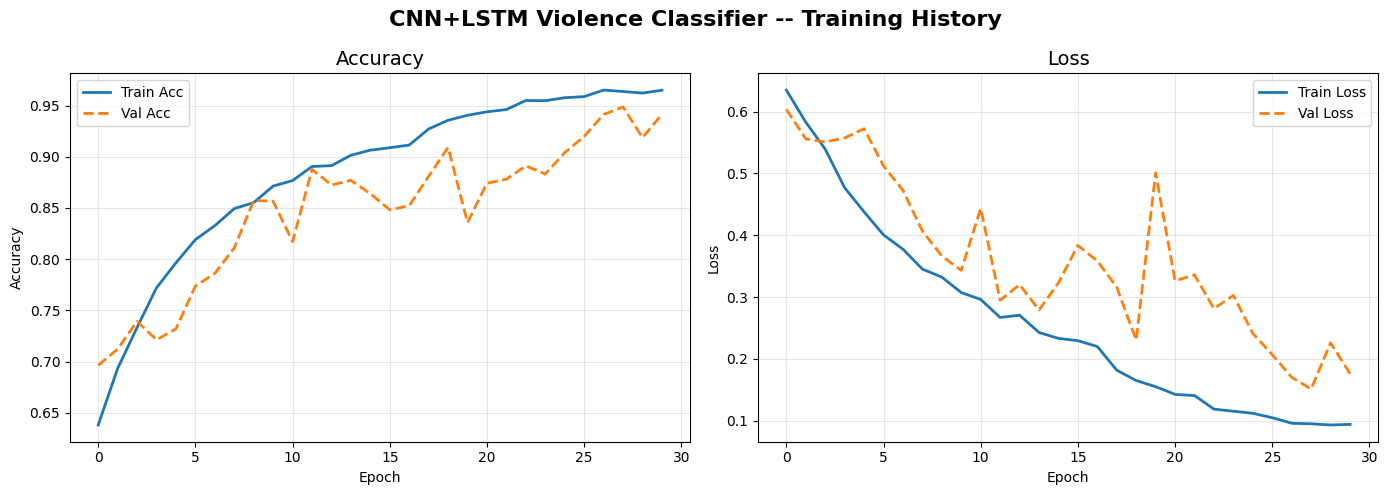

Best val_accuracy : 0.9486
Best val_loss     : 0.1512


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
axes[0].set_title('Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title('Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN+LSTM Violence Classifier -- Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_acc  = max(history.history['val_accuracy'])
best_loss = min(history.history['val_loss'])
print(f'Best val_accuracy : {best_acc:.4f}')
print(f'Best val_loss     : {best_loss:.4f}')

In [11]:
import cv2
import numpy as np

video_path = "/Users/riishabhjain/Desktop/Violence_Detector/CRAZY_STUNT_FIGHT_TonyFA_shorts_stunt_stunts_actor_trending_howto_360P.mp4"

def predict_video(video_path, trained_model, sequence_length=20, img_w=64, img_h=64):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Could not open video.")
        return

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Resize to 64x64
        frame = cv2.resize(frame, (img_w, img_h), interpolation=cv2.INTER_LINEAR)
        frames.append(frame)
    cap.release()
    
    if len(frames) < sequence_length:
        print("Video is too short (under 20 frames).")
        return
    
    # Take center sequence of 20 frames
    start_idx = (len(frames) - sequence_length) // 2
    window = np.stack(
        [frames[start_idx + i].astype(np.float32) / 255.0 for i in range(sequence_length)],
        axis=0
    )
    # Add batch dimension
    window = np.expand_dims(window, axis=0)
    
    # Predict
    prob = trained_model.predict(window)[0][0]
    verdict = "Violence" if prob >= 0.5 else "NonViolence"
    print("--- Prediction ---")
    print(f"Video:   {video_path}")
    print(f"Verdict: {verdict}")
    print(f"Score:   {prob:.4f}")

predict_video(video_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
--- Prediction ---
Video:   /Users/riishabhjain/Desktop/Violence_Detector/CRAZY_STUNT_FIGHT_TonyFA_shorts_stunt_stunts_actor_trending_howto_360P.mp4
Verdict: Violence
Score:   0.8256


[INFO] Weights loaded.
[INFO] Total videos to evaluate: 4000
  [  44/4000] VIO  V_681.mp4                            score=0.395  NON-VIOLENT  ✗
  [  50/4000] VIO  V_905.mp4                            score=0.999  VIOLENT      ✓
  [ 100/4000] VIO  V_331.mp4                            score=0.995  VIOLENT      ✓
  [ 104/4000] VIO  V_682.mp4                            score=0.352  NON-VIOLENT  ✗
  [ 150/4000] VIO  V_309.mp4                            score=0.999  VIOLENT      ✓
  [ 200/4000] VIO  V_28.mp4                             score=0.999  VIOLENT      ✓
  [ 229/4000] VIO  V_684.mp4                            score=0.434  NON-VIOLENT  ✗
  [ 250/4000] VIO  V_257.mp4                            score=0.999  VIOLENT      ✓
  [ 300/4000] VIO  V_147.mp4                            score=0.977  VIOLENT      ✓
  [ 307/4000] VIO  V_796.mp4                            score=0.460  NON-VIOLENT  ✗
  [ 350/4000] VIO  V_347.mp4                            score=0.999  VIOLENT      ✓
  [ 400/4000] V

[h264 @ 0xc8e9dce00] mb_type 104 in P slice too large at 98 31
[h264 @ 0xc8e9dce00] error while decoding MB 98 31


  [2950/4000] NV   NV_40.mp4                            score=0.096  NON-VIOLENT  ✓
  [2965/4000] NV   NV_361.mp4                           score=0.640  VIOLENT      ✗
  [3000/4000] NV   NV_200.mp4                           score=0.002  NON-VIOLENT  ✓
  [3050/4000] NV   NV_620.mp4                           score=0.001  NON-VIOLENT  ✓
  [3064/4000] NV   NV_740.mp4                           score=0.620  VIOLENT      ✗
  [3081/4000] NV   NV_583.mp4                           score=0.619  VIOLENT      ✗
  [3100/4000] NV   NV_811.mp4                           score=0.002  NON-VIOLENT  ✓
  [3140/4000] NV   NV_582.mp4                           score=0.826  VIOLENT      ✗
  [3150/4000] NV   NV_545.mp4                           score=0.066  NON-VIOLENT  ✓
  [3153/4000] NV   NV_586.mp4                           score=0.926  VIOLENT      ✗
  [3200/4000] NV   NV_961.mp4                           score=0.002  NON-VIOLENT  ✓
  [3250/4000] NV   NV_803.mp4                           score=0.001  NON-VIO

[h264 @ 0xc8e9dc700] mb_type 104 in P slice too large at 98 31
[h264 @ 0xc8e9dc700] error while decoding MB 98 31


  [3950/4000] NV   NV_40.mp4                            score=0.096  NON-VIOLENT  ✓
  [3965/4000] NV   NV_361.mp4                           score=0.640  VIOLENT      ✗
  [4000/4000] NV   NV_200.mp4                           score=0.002  NON-VIOLENT  ✓

------------------------------------------------------------
  TP=1978  TN=1974  FP=26  FN=22  (N=4000 videos)
  Accuracy  = 98.80%
  Precision = 0.9870
  Recall    = 0.9890
  F1-Score  = 0.9880
------------------------------------------------------------


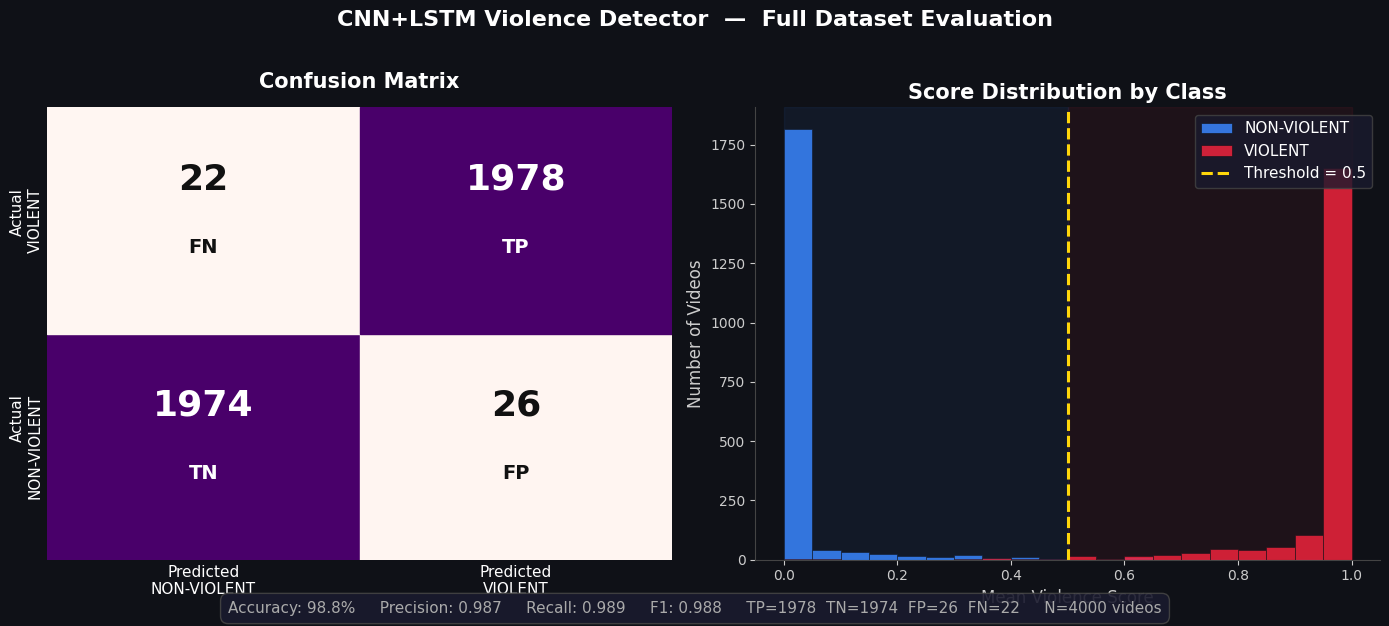

[INFO] Saved → confusion_matrix_full.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# Confusion Matrix — CNN+LSTM model on ALL data (no YOLO, pure frame-based)
# Tests every video in Violence/, Violence_2/, NonViolence/, NonViolence_2/
# ═══════════════════════════════════════════════════════════════════════
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# ── Config (must match training) ────────────────────────────────────
# All folders that contain violence/non-violence videos
VIOLENCE_DIRS     = ['./Violence', './Violence_2']
NON_VIOLENCE_DIRS = ['./NonViolence', './NonViolence_2']
WEIGHTS_PATH      = './model_weights.weights.h5'
SEQ_LEN           = 20
IMG_H, IMG_W      = 64, 64
THRESH            = 0.5
VIDEO_EXTS        = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.webm'}

# ── Load model weights ───────────────────────────────────────────────
cnn_lstm = create_cnn_lstm()
cnn_lstm.load_weights(WEIGHTS_PATH)
print('[INFO] Weights loaded.')

# ── Frame-based inference (no YOLO) ─────────────────────────────────
def get_score(video_path):
    """Extract up to 3 non-overlapping 20-frame sequences, return mean prob."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(cv2.resize(frame, (IMG_W, IMG_H)).astype(np.float32) / 255.0)
    cap.release()
    if len(frames) < SEQ_LEN: return None

    n_possible = len(frames) // SEQ_LEN
    n_take     = min(3, n_possible)
    indices    = np.linspace(0, n_possible - 1, n_take, dtype=int)
    probs = []
    for idx in indices:
        seq  = np.stack(frames[idx*SEQ_LEN : idx*SEQ_LEN + SEQ_LEN], axis=0)
        seq  = np.expand_dims(seq, axis=0)
        prob = float(cnn_lstm.predict(seq, verbose=0)[0][0])
        probs.append(prob)
    return float(np.mean(probs))

# ── Collect ALL video paths ──────────────────────────────────────────
def collect_all(folders, label):
    files = []
    for folder in folders:
        p = Path(folder)
        if p.is_dir():
            files += [(f, label) for f in p.iterdir() if f.suffix.lower() in VIDEO_EXTS]
    return files

all_samples = collect_all(VIOLENCE_DIRS, 1) + collect_all(NON_VIOLENCE_DIRS, 0)
total = len(all_samples)
print(f'[INFO] Total videos to evaluate: {total}')

# ── Run inference on everything ──────────────────────────────────────
y_true, y_pred, all_scores = [], [], []

for i, (vpath, label) in enumerate(all_samples, 1):
    score = get_score(str(vpath))
    if score is None:
        print(f'  [{i:>4}/{total}] SKIP (too short)  {vpath.name}')
        continue
    pred     = 1 if score >= THRESH else 0
    correct  = pred == label
    y_true.append(label); y_pred.append(pred); all_scores.append(score)
    tag  = '\u2713' if correct else '\u2717'
    cls  = 'VIO' if label == 1 else 'NV '
    pred_str = 'VIOLENT' if pred else 'NON-VIOLENT'
    if i % 50 == 0 or not correct:   # print every 50th + every mistake
        print(f'  [{i:>4}/{total}] {cls}  {vpath.name:<35}  score={score:.3f}  {pred_str:<12} {tag}')

# ── Confusion matrix values ──────────────────────────────────────────
y_true = np.array(y_true); y_pred = np.array(y_pred)
TP = int(np.sum((y_true==1)&(y_pred==1)))
TN = int(np.sum((y_true==0)&(y_pred==0)))
FP = int(np.sum((y_true==0)&(y_pred==1)))
FN = int(np.sum((y_true==1)&(y_pred==0)))

acc       = (TP+TN)/len(y_true)*100
precision = TP/(TP+FP) if (TP+FP)>0 else 0
recall    = TP/(TP+FN) if (TP+FN)>0 else 0
f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print(f'\n{"-"*60}')
print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}  (N={len(y_true)} videos)')
print(f'  Accuracy  = {acc:.2f}%')
print(f'  Precision = {precision:.4f}')
print(f'  Recall    = {recall:.4f}')
print(f'  F1-Score  = {f1:.4f}')
print(f'{"-"*60}')

# ── Plot ─────────────────────────────────────────────────────────────
BG   = '#0f1117'
CARD = '#1a1a2e'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# Left — Confusion matrix heatmap
ax = axes[0]
ax.set_facecolor(BG)
cm = np.array([[TN, FP], [FN, TP]], dtype=float)
cmap = plt.get_cmap('RdPu')
vmax = max(TP, TN, FP, FN, 1)
colors = [[cmap(cm[r,c]/vmax) for c in range(2)] for r in range(2)]
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for r in range(2):
    for c in range(2):
        val = int(cm[r, c])
        rect = plt.Rectangle([c-0.5, r-0.5], 1, 1, color=colors[r][c])
        ax.add_patch(rect)
        brightness = 0.299*colors[r][c][0] + 0.587*colors[r][c][1] + 0.114*colors[r][c][2]
        txt_color  = 'white' if brightness < 0.6 else '#111'
        ax.text(c, r-0.12, cell_labels[r][c], ha='center', va='center',
                fontsize=14, color=txt_color, fontweight='bold')
        ax.text(c, r+0.18, str(val), ha='center', va='center',
                fontsize=26, color=txt_color, fontweight='bold')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Predicted\nNON-VIOLENT', 'Predicted\nVIOLENT'], color='white', fontsize=11)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Actual\nNON-VIOLENT', 'Actual\nVIOLENT'],
                   color='white', fontsize=11, rotation=90, va='center')
ax.set_title('Confusion Matrix', color='white', fontsize=15, fontweight='bold', pad=14)
ax.tick_params(colors='white', length=0)
for spine in ax.spines.values(): spine.set_visible(False)

# Right — Score distribution
ax2 = axes[1]
ax2.set_facecolor(BG)
vio_scores  = [s for s,t in zip(all_scores, y_true) if t == 1]
nvio_scores = [s for s,t in zip(all_scores, y_true) if t == 0]
bins = np.linspace(0, 1, 21)
ax2.hist(nvio_scores, bins=bins, color='#3a86ff', alpha=0.85, label='NON-VIOLENT', edgecolor='#0f1117', linewidth=0.5)
ax2.hist(vio_scores,  bins=bins, color='#ef233c', alpha=0.85, label='VIOLENT',     edgecolor='#0f1117', linewidth=0.5)
ax2.axvline(THRESH, color='#ffd60a', linestyle='--', linewidth=2.2, label=f'Threshold = {THRESH}')
ax2.axvspan(THRESH, 1.0, alpha=0.07, color='#ef233c')
ax2.axvspan(0.0, THRESH, alpha=0.07, color='#3a86ff')
ax2.set_xlabel('Mean Violence Score', color='#cccccc', fontsize=12)
ax2.set_ylabel('Number of Videos',   color='#cccccc', fontsize=12)
ax2.set_title('Score Distribution by Class', color='white', fontsize=15, fontweight='bold')
ax2.tick_params(colors='#cccccc')
for side in ['top','right']: ax2.spines[side].set_visible(False)
for side in ['bottom','left']: ax2.spines[side].set_color('#444')
legend = ax2.legend(fontsize=11, facecolor=CARD, edgecolor='#444')
for txt in legend.get_texts(): txt.set_color('white')

# Bottom metrics strip
fig.text(0.5, 0.01,
         f'Accuracy: {acc:.1f}%     Precision: {precision:.3f}     '
         f'Recall: {recall:.3f}     F1: {f1:.3f}     '
         f'TP={TP}  TN={TN}  FP={FP}  FN={FN}     N={len(y_true)} videos',
         ha='center', va='bottom', color='#aaaaaa', fontsize=11,
         bbox=dict(boxstyle='round,pad=0.5', facecolor=CARD, edgecolor='#444', alpha=0.9))

plt.suptitle('CNN+LSTM Violence Detector  —  Full Dataset Evaluation',
             color='white', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
out = 'confusion_matrix_full.png'
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'[INFO] Saved \u2192 {out}')
